In [58]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [59]:
import pandas as pd

from src.topic_modeling import (
    LDATopicModel
)

In [60]:
df = pd.read_csv(
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/data/processed/cleaned_news.csv"
)

print(df.shape)

df.head()

(32770, 6)


,Headlines,Time,Description,text,clean_text,length
0,TikTok considers London and other locations fo...,2020-07-18,TikTok has been in discussions with the UK gov...,TikTok considers London and other locations fo...,tiktok considers london and other locations fo...,47
1,Disney cuts ad spending on Facebook amid growi...,2020-07-18,Walt Disney has become the latest company to ...,Disney cuts ad spending on Facebook amid growi...,disney cuts ad spending on facebook amid growi...,56
2,Trail of missing Wirecard executive leads to B...,2020-07-18,Former Wirecard chief operating officer Jan M...,Trail of missing Wirecard executive leads to B...,trail of missing wirecard executive leads to b...,40
3,Twitter says attackers downloaded data from up...,2020-07-18,Twitter Inc said on Saturday that hackers were...,Twitter says attackers downloaded data from up...,twitter says attackers downloaded data from up...,47
4,U.S. Republicans seek liability protections as...,2020-07-17,A battle in the U.S. Congress over a new coron...,U.S. Republicans seek liability protections as...,u s republicans seek liability protections as ...,50


In [61]:
lda_model = LDATopicModel(
    n_topics=12
)

lda_model.fit(
    df["clean_text"]
)

In [62]:
topics_df = (
    lda_model
    .topics_dataframe(
        top_n_words=30
    )
)

topics_df

,topic_id,keywords
0,0,"gains, fell, high, central bank, stock, world,..."
1,1,"trading, cuts, job, ryanair, bayer, short, cap..."
2,2,"lufthansa, federal, united, plane, flight, tra..."
3,3,"xi, deal, trump says, lawmakers, talks, billio..."
4,4,"vehicle, plans, management, told, fund, techno..."
5,5,"washington, government, secretary, dispute, ta..."
6,6,"disney, giant, stores, digital, delivery, laun..."
7,7,"general motors, sales, spread, amid, auto, car..."
8,8,"market, second quarter, hit, self, costs, resu..."
9,9,"plans, bid, china, euros, unit, sell, fund, me..."


In [63]:
topics_df.to_csv(
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/tables/topics.csv",
    index=False
)

In [64]:
df = (
    lda_model
    .add_topics_to_dataframe(df)
)

In [65]:
TOPIC_NAMES = {
    0: "Macroeconomy & Financial Markets",
    1: "Banking & Financial Services",
    2: "Aviation & Air Transportation",
    3: "US-China Trade War & Geopolitics",
    4: "Automotive Industry & Corporate Leadership",
    5: "International Trade & Economic Policy",
    6: "Big Tech & Digital Platforms",
    7: "COVID-19, Manufacturing & Labor Markets",
    8: "Corporate Earnings & Equity Markets",
    9: "Mergers & Acquisitions",
    10: "Oil & Energy Markets",
    11: "Financial Regulation & Corporate Scandals"
}

In [66]:
df["topic_name"] = (
    df["topic"]
    .map(TOPIC_NAMES)
)

In [67]:
topic_counts = (
    df["topic_name"]
    .value_counts()
)

topic_counts

topic_name
Macroeconomy & Financial Markets              3903
Big Tech & Digital Platforms                  3356
Automotive Industry & Corporate Leadership    3345
Mergers & Acquisitions                        3249
Financial Regulation & Corporate Scandals     2735
COVID-19, Manufacturing & Labor Markets       2654
Banking & Financial Services                  2493
International Trade & Economic Policy         2387
Corporate Earnings & Equity Markets           2379
Aviation & Air Transportation                 2247
US-China Trade War & Geopolitics              2177
Oil & Energy Markets                          1845
Name: count, dtype: int64

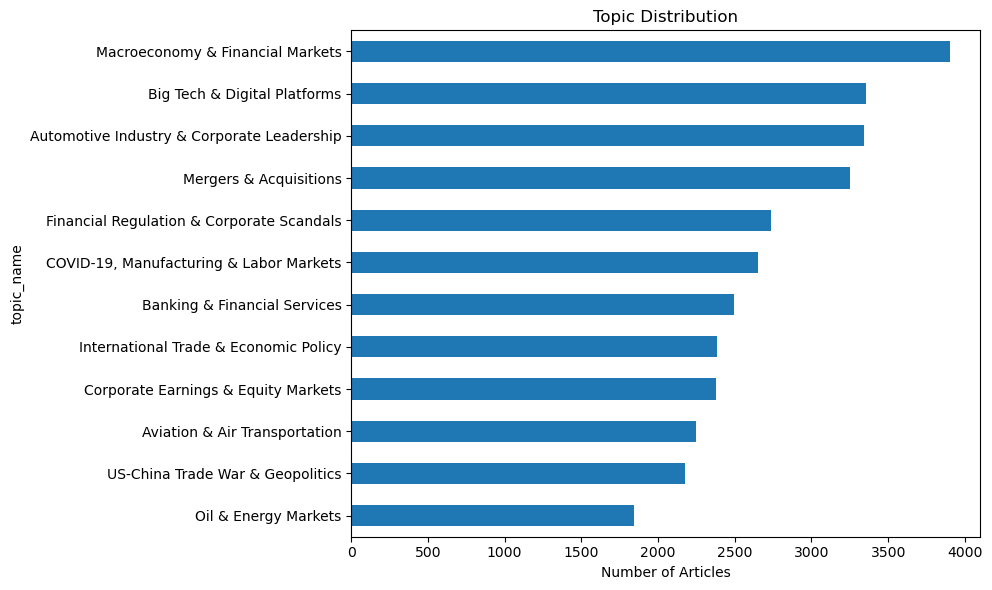

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

topic_counts.sort_values().plot(
    kind="barh"
)

plt.title(
    "Topic Distribution"
)

plt.xlabel(
    "Number of Articles"
)

plt.tight_layout()

plt.show()

In [69]:
for topic in range(12):

    print(
        f"\n{'='*25}"
    )

    print(
        f"Topic {topic}: "
        f"{TOPIC_NAMES[topic]}"
    )

    print(
        topics_df.loc[
            topics_df["topic_id"] == topic,
            "keywords"
        ].values[0]
    )

    display(
        df.loc[
            df["topic"] == topic,
            ["Headlines"]
        ].head(5)
    )


Topic 0: Macroeconomy & Financial Markets
gains, fell, high, central bank, stock, world, record, dollar, market, bank, data, central, rate, rates, investors, markets, fed, federal reserve, economic, federal, reserve, growth, wall street, trade, china, street, wall, economy, global, stocks


,Headlines
11,S&P 500 ends higher as traders weigh stimulus ...
13,Where did all the bulls go? Rallies stall as E...
14,BlackRock profit beats Street estimates as mar...
15,"Dollar falls, euro hovers at four-month high a..."
25,Euro zone shares flat as EU recovery plan awai...



Topic 1: Banking & Financial Services
trading, cuts, job, ryanair, bayer, short, capital, long, credit, british, term, funds, pay, york, new york, home, big, london, exchange, crisis, jpmorgan, financial, cash, investors, bank, america, stock, new, market, banks


,Headlines
5,Wall Street Week Ahead: Fund managers navigate...
10,Delta will avoid pilot furloughs if they agree...
22,"On eve of bankruptcy, U.S. firms shower execs ..."
30,As big U.S. banks let customers delay payments...
32,Exclusive: Thyssenkrupp to explore further opt...



Topic 2: Aviation & Air Transportation
lufthansa, federal, united, plane, flight, travel, airways, grounded, planemaker, crash, planes, carrier, order, safety, new, hong kong, kong, hong, jets, aviation, flights, jet, boeing max, aircraft, airline, airbus, air, max, airlines, boeing


...

,Headlines
0,TikTok considers London and other locations fo...
17,"Exclusive: EU in talks with Moderna, BioNtech,..."
23,Rival parties take aim at Germany's Scholz ove...
31,"UBS, Morgan Stanley expected to lead Vodafone ..."
40,Italy plans listing for Autostrade by early 20...



Topic 10: Oil & Energy Markets
petroleum, oil gas, exxon, producer, producers, venezuela, cuts, saudi aramco, cut, russian, state, global, production, aramco, demand, saudi arabia, arabia, gas, output, sanctions, iran, russia, opec, supply, oil prices, crude, energy, saudi, prices, oil


,Headlines
42,Former Pemex boss Lozoya taken to hospital aft...
78,Oil falls as OPEC+ plans to raise output while...
93,Oil giants including Exxon set first joint car...
165,Oil climbs 2% on U.S. stock draw but gains cap...
166,OPEC+ eases record oil cuts as economy recover...



Topic 11: Financial Regulation & Corporate Scandals
wells, money, watchdog, familiar, commission, securities, matter, prosecutors, department, charges, investigation, scandal, reported citing, regulator, bloomberg, financial, lawsuit, case, citing, german, judge, federal, deutsche bank, probe, pay, reported, deutsche, million, court, bank


,Headlines
12,FTC considering deposing top Facebook executiv...
44,Stripe wins business following Wirecard's coll...
48,Deutsche Boerse proposes new rules for quick D...
54,Westpac says regulator-ordered report finds go...
60,Jailed executive in Wirecard scandal offers co...


In [70]:
df.to_csv(
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/data/processed/topic_assignments.csv",
    index=False
)

In [72]:
import joblib

joblib.dump(
    lda_model,
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/models/lda_model.pkl"
)

['/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/models/lda_model.pkl']